# Quantum teleportation in MBQC
on a four-qubit linear cluster

## References
- _A One-Way Quantum Computer_, Raussendorf R. and Briegel H.J., Phys. Rev. Lett., 86, 22, 5188--5191, 2001, American Physical Society, [url](https://link.aps.org/doi/10.1103/PhysRevLett.86.5188)


## Environment setup

The following cells install the dependencies and set the working directory to the folder containing this notebook. You may need to restart the kernel after installing the dependencies.

On Google Colab, setup clones the repository (`main` branch) and selects the example directory before installing dependencies. If prompted, restart the runtime and rerun the cells. The clone is reused within the same session; start a fresh Colab session to fetch updates from GitHub.


In [ ]:
from pathlib import Path
import os
import subprocess

try:
    import google.colab
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    repository = Path("/content/mbqc-codes")
    if not repository.exists():
        subprocess.run([
            "git", "clone", "--depth", "1", "--branch", "main",
            "https://github.com/AlbertoMiserendino/mbqc-codes.git",
            str(repository),
        ], check=True)
    os.chdir(repository / "01-mbqc-teleport")

%pip install -r "../requirements.txt" -q
# If prompted, restart the runtime/kernel and run the cells again.


In [2]:
from pathlib import Path
import os
import ipynbname

# Automated runs already start in the notebook directory.
if not Path("mbqc-teleport-v1a.qasm").is_file():
    os.chdir(ipynbname.path().parent)


/home/alberto/qc/01-mbqc-teleport


## MBQC circuits for teleportation

Consider a four-qubit linear cluster

$$
q_0 - q_1 - q_2 - q_3,
$$

where $q_0$ holds the arbitrary state to be teleported,

$$
|\psi\rangle =
R_z(\phi)R_y(\theta)|0\rangle
\sim
\cos\frac{\theta}{2}|0\rangle
+ e^{i\phi}\sin\frac{\theta}{2}|1\rangle,
$$

while $q_1,q_2,q_3$ are initialized in $|+\rangle$. The cluster connections are implemented using $CZ$ gates.

The next two cells load and display two OpenQASM variants of the circuit.

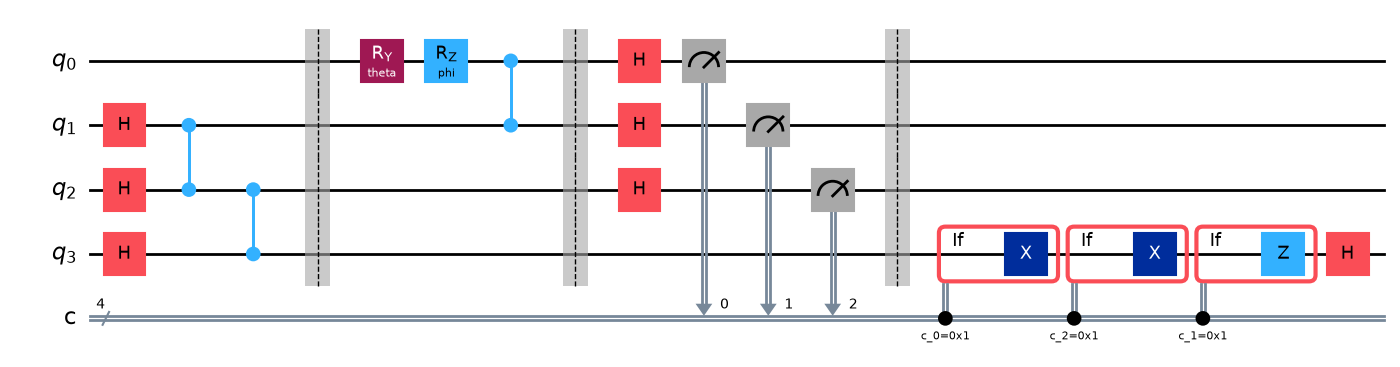

In [3]:
from qiskit import qasm3

qc = qasm3.load(
    "mbqc-teleport-v1a.qasm"
    )

qc.draw("mpl")

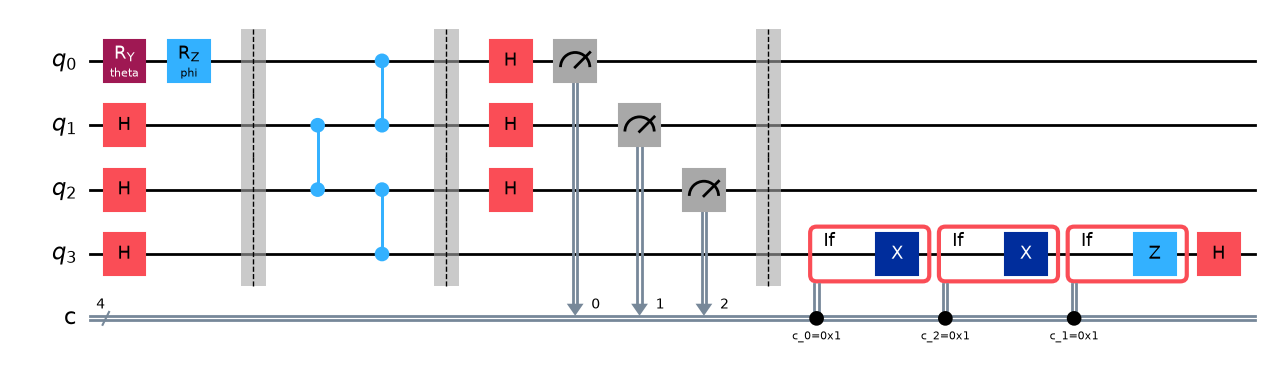

In [4]:
from qiskit import qasm3

qc = qasm3.load(
    "mbqc-teleport-v1b.qasm"
    )

qc.draw("mpl")

In this configuration, preparing a qubit in the desired state and then entangling it with $\left|+\right\rangle^{\otimes N}$ using $S$ is equivalent to creating $S\left|+\right\rangle^{\otimes N}$ and coupling the input qubit to it with a $CZ$ gate. Only the definition of the operator $S$ changes.

## Feed-forward and Pauli corrections

Each elementary teleportation step along the cluster produces

$$
|\psi\rangle \longrightarrow X^{m}H|\psi\rangle,
$$

where $m\in\{0,1\}$ is the outcome of the measurement in the $X$ basis.

Three consecutive measurements yield

$$
|\psi_{\mathrm{out}}\rangle
=
X^{m_2}H\,X^{m_1}H\,X^{m_0}H|\psi\rangle.
$$

The operators $X$ and $H$ **do not commute**. Instead, we use the identities

$$
HX^m = Z^mH,
\qquad
HZ^m = X^mH.
$$

Step by step:

$$
X^{m_1}H X^{m_0}H|\psi\rangle
=
X^{m_1}Z^{m_0}|\psi\rangle,
$$

and therefore

$$
X^{m_2}H X^{m_1}Z^{m_0}|\psi\rangle
=
X^{m_2}Z^{m_1}X^{m_0}H|\psi\rangle.
$$

Up to a global phase,

$$
\boxed{
|\psi_{\mathrm{out}}\rangle
=
X^{m_0\oplus m_2} Z^{m_1} H|\psi\rangle
}.
$$

Feed-forward must therefore apply $X^{m_0\oplus m_2}$, $Z^{m_1}$ and finally $H$ to recover $|\psi\rangle$. The final $H$ is needed only when the number of teleportation steps is odd; here there are three.

The operator $X^{m_0\oplus m_2}$ can be implemented without explicitly computing the XOR:

$$
X^{m_0}X^{m_2}=X^{m_0\oplus m_2},
$$

since $X^2=I$. In OpenQASM, it is therefore sufficient to apply one $X$ conditioned on $m_0$ and a second $X$ conditioned on $m_2$.

## Input state parameters

The angles $\theta$ and $\phi$ determine the point on the Bloch sphere. In this section, we identify the symbolic circuit parameters and assign numerical values to run the simulation.

For the state

$$
|\psi\rangle =
\cos\frac{\theta}{2}|0\rangle
+ e^{i\phi}\sin\frac{\theta}{2}|1\rangle,
$$

the theoretical Bloch vector is

$$
\mathbf r =
\left(
\sin\theta\cos\phi,\;
\sin\theta\sin\phi,\;
\cos\theta
\right).
$$

In [5]:
print(qc.num_parameters)
print(qc.parameters)

2
ParameterView([Parameter(phi), Parameter(theta)])


In [6]:
params = {p.name: p for p in qc.parameters}

import numpy as np
theta_value = np.pi / 2
phi_value = np.pi / 4

import numpy as np
qc_bound = qc.assign_parameters({
    params["theta"]: theta_value,
    params["phi"]: phi_value
})

In [7]:
print(qc_bound.parameters)

ParameterView([])


## Verifying the teleported state

After teleportation, the output qubit is $q_3$. To verify that it contains the initial state, we estimate the three Bloch vector components: $\langle X\rangle$, $\langle Y\rangle$ and $\langle Z\rangle$.

Measurement in the $Z$ basis is direct. To measure in the other bases, we first change basis:

$$
M_X = M_Z H,
\qquad
M_Y = M_Z H S^\dagger.
$$

Three circuit copies are therefore created, one for each measurement basis.

In [8]:
qc_z = qc_bound.copy()
qc_z.measure(3, 3)

qc_x = qc_bound.copy()
qc_x.h(3)
qc_x.measure(3, 3)

qc_y = qc_bound.copy()
qc_y.sdg(3)
qc_y.h(3)
qc_y.measure(3, 3)

## Simulation

The circuit is executed many times (shots) with `AerSimulator`. The counts obtained in the $X$, $Y$ and $Z$ bases allow us to reconstruct the Bloch vector of qubit $q_3$ from the measurements.

In [9]:
from qiskit_aer import AerSimulator
sim = AerSimulator()

shots = 10000

result_x = sim.run(qc_x, shots=shots).result()
result_y = sim.run(qc_y, shots=shots).result()
result_z = sim.run(qc_z, shots=shots).result()

counts_x = result_x.get_counts()
counts_y = result_y.get_counts()
counts_z = result_z.get_counts()

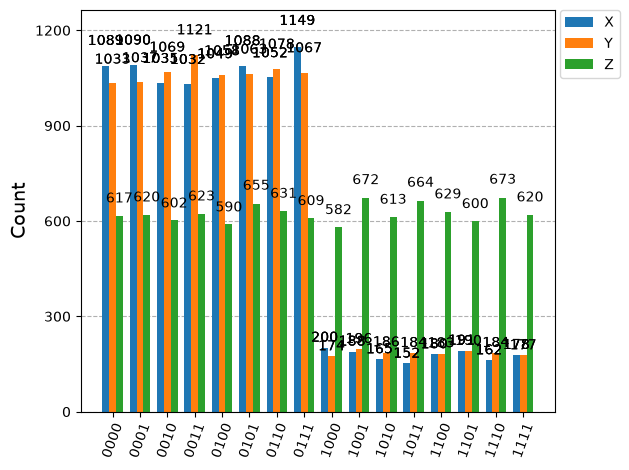

In [10]:
from qiskit.visualization import plot_histogram
from IPython.display import display

display(plot_histogram([counts_x, counts_y, counts_z],
                       legend=["X", "Y", "Z"]))

## Marginalizing to the output qubit

The circuit also contains classical bits from the MBQC measurements. For the final verification, however, only the measurement outcome of $q_3$ is relevant.

We therefore extract the marginal counts for the classical bit associated with the output qubit.

In [11]:
from qiskit.result import marginal_counts
mx = marginal_counts(counts_x, indices=[3])
my = marginal_counts(counts_y, indices=[3])
mz = marginal_counts(counts_z, indices=[3])

print("X:", mx)
print("Y:", my)
print("Z:", mz)

X: {'1': 1416, '0': 8584}
Y: {'1': 1474, '0': 8526}
Z: {'0': 4947, '1': 5053}


## Expectation values

For a Pauli measurement $P\in\{X,Y,Z\}$ with outcomes encoded as $0$ and $1$, the expectation value is estimated as

$$
\langle P\rangle =
\frac{N_0-N_1}{N_0+N_1}.
$$

The three resulting quantities form the measured Bloch vector

$$
\mathbf r_{\mathrm{meas}}
=
\bigl(
\langle X\rangle,
\langle Y\rangle,
\langle Z\rangle
\bigr).
$$

In [12]:
def expectation(counts):
    n0 = counts.get("0", 0)
    n1 = counts.get("1", 0)

    return (n0 - n1) / (n0 + n1)


x_meas = expectation(mx)
y_meas = expectation(my)
z_meas = expectation(mz)

print("<X> =", x_meas)
print("<Y> =", y_meas)
print("<Z> =", z_meas)

<X> = 0.7168
<Y> = 0.7052
<Z> = -0.0106


## Comparison with the theoretical result

For the state prepared by $R_y(\theta)$ followed by $R_z(\phi)$, the theoretical values are

$$
\langle X\rangle = \sin\theta\cos\phi,
\qquad
\langle Y\rangle = \sin\theta\sin\phi,
\qquad
\langle Z\rangle = \cos\theta.
$$

If teleportation and feed-forward are correct, these values should agree with the simulation results within statistical uncertainty.

In [13]:
x_theory = np.sin(theta_value) * np.cos(phi_value)
y_theory = np.sin(theta_value) * np.sin(phi_value)
z_theory = np.cos(theta_value)

print("Theoretical:")
print("<X> =", x_theory)
print("<Y> =", y_theory)
print("<Z> =", z_theory)

Theoretical:
<X> = 0.7071067811865476
<Y> = 0.7071067811865475
<Z> = 6.123233995736766e-17


## Fidelity

For a pure target state with Bloch vector $\mathbf r_{\mathrm{th}}$ and a reconstructed state with vector $\mathbf r_{\mathrm{meas}}$, the fidelity is

$$
F =
\frac{1+\mathbf r_{\mathrm{th}}\cdot\mathbf r_{\mathrm{meas}}}{2}.
$$

Because of statistical fluctuations due to the finite number of shots, the norm of the reconstructed vector may be slightly larger than $1$. The following cell projects it back onto the Bloch sphere before calculating the fidelity.

In [14]:
r_meas = np.array([x_meas, y_meas, z_meas])
norm = np.linalg.norm(r_meas)
if norm > 1:
    r_meas = r_meas / norm

In [15]:
r_theory = np.array([
    x_theory,
    y_theory,
    z_theory
])

fidelity = (1 + np.dot(r_theory, r_meas)) / 2

In [16]:
print("Fidelity =", fidelity)

Fidelity = 0.9999555863987409
